# 03: Time-Frequency Wavelet Analysis & Synchrosqueezing (SST)

### 🔬 Motivating Scientific Question
> **How can we track transient, non-stationary scintillation events and chirp bursts that evolve dynamically over time without losing frequency resolution?**

---


## 1. Non-Stationary Signal Synthesis (Harmonic + Chirp Burst)

### ❓ Why Time-Frequency Wavelet Analysis?
Traditional Fourier transforms (FFT) compute global frequency spectra averaged over the entire observation window, completely obscuring *when* spectral changes happen. Short-Time Fourier Transforms (STFT) introduce fixed window length trade-offs (Heisenberg-Gabor uncertainty limit). **Continuous Wavelet Transforms (CWT)** provide multi-resolution scale-space decomposition, using narrow wavelets for high-frequency transients and wide wavelets for low-frequency oscillations.

We synthesize a 600-sample non-stationary signal containing:
1. **Stationary Harmonic Mode**: $T_1 = 12.0\text{ s}$ ($f_1 = 0.0833\text{ Hz}$)
2. **Transient Chirp Burst**: $f(t) = 0.04 \to 0.12\text{ Hz}$ centered at $t = 300\text{ s}$


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
import numpy as np
from ssqueezepy import Wavelet, ssq_cwt

from core.synthetic_generator import generate_synthetic_scintillation

SEED = 42
FS = 1.0
LENGTH = 600
t = np.arange(LENGTH) / FS

# Generate stationary base signal (harmonic T1=12s)
sig_base, _ = generate_synthetic_scintillation(
    length=LENGTH,
    fs=FS,
    f_fresnel=0.1,
    spectral_index=8.0 / 3.0,
    harmonics=[(12.0, 1.0)],
    white_noise_std=0.1,
    seed=SEED,
)

# Add transient Gaussian-windowed chirp burst (0.04 to 0.12 Hz centered at t=300s)
f0, f1_chirp = 0.04, 0.12
chirp_envelope = np.exp(-(((t - 300.0) / 60.0) ** 2))
chirp_phase = 2 * np.pi * (f0 * t + 0.5 * (f1_chirp - f0) * (t**2 / LENGTH))
chirp_burst = 1.2 * np.sin(chirp_phase) * chirp_envelope

sig_nonstat = sig_base + chirp_burst

print(f"Non-stationary signal generated: {LENGTH} samples. Chirp burst active around t=300s.")

Non-stationary signal generated: 600 samples. Chirp burst active around t=300s.


## 2. Wavelet Family Comparison (Morlet vs. Generalized Morse Wavelets)

### ❓ Why Generalized Morse Wavelets (`gmw`)?
Standard Morlet wavelets are symmetric Gaussian-windowed complex exponentials. While effective, Morlet wavelets suffer from energy leakage at boundary scales. **Generalized Morse Wavelets (`gmw`, $\gamma=3, \beta=30$)** offer precise control over time-bandwidth duration and phase symmetry, maximizing energy concentration for oscillatory plasma transients while minimizing scale blur.


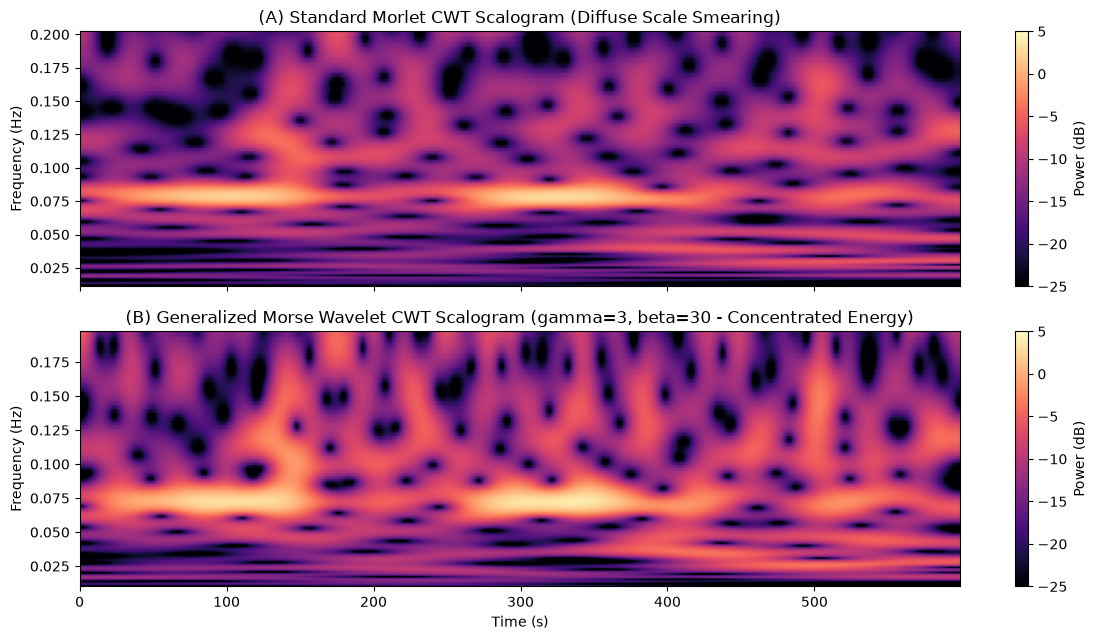

In [2]:
# Compare Morlet vs. Morse Wavelets
morlet_w = Wavelet("morlet")
morse_w = Wavelet(("gmw", {"gamma": 3, "beta": 30}))

_, Wx_morlet, freqs_m, _ = ssq_cwt(sig_nonstat, wavelet=morlet_w, fs=FS, nv=32)
_, Wx_morse, freqs_g, _ = ssq_cwt(sig_nonstat, wavelet=morse_w, fs=FS, nv=32)

cwt_m_db = 20 * np.log10(np.maximum(np.abs(Wx_morlet), 1e-6))
cwt_g_db = 20 * np.log10(np.maximum(np.abs(Wx_morse), 1e-6))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

v_mask = (freqs_g >= 0.01) & (freqs_g <= 0.2)
idx_v = np.where(v_mask)[0]

m1 = ax1.pcolormesh(t, freqs_m[idx_v], cwt_m_db[idx_v, :], shading="gouraud", cmap="magma", vmin=-25, vmax=5)
ax1.set_ylabel("Frequency (Hz)")
ax1.set_title("(A) Standard Morlet CWT Scalogram (Diffuse Scale Smearing)")
fig.colorbar(m1, ax=ax1, label="Power (dB)")

m2 = ax2.pcolormesh(t, freqs_g[idx_v], cwt_g_db[idx_v, :], shading="gouraud", cmap="magma", vmin=-25, vmax=5)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Frequency (Hz)")
ax2.set_title("(B) Generalized Morse Wavelet CWT Scalogram (gamma=3, beta=30 - Concentrated Energy)")
fig.colorbar(m2, ax=ax2, label="Power (dB)")

plt.tight_layout()
plt.show()

### 💡 Scientific Interpretation: Wavelet Energy Concentration
- **Scale Smearing Reduction**: Panel A (Morlet) exhibits vertical scale blurring around $f = 0.0833\text{ Hz}$. Panel B (Morse $\gamma=3, \beta=30$) compresses the energy footprint, isolating the stationary harmonic band from the rising chirp trajectory.

## 3. Synchrosqueezed Wavelet Transform (SST) & Energy Reassignment

### ❓ Why Synchrosqueezing (SST)?
CWT scalograms blur energy across adjacent scales due to the finite duration of wavelet basis functions. **Synchrosqueezing (SST)** computes the local instantaneous frequency $\omega(a, b) = -i \frac{\partial_b W(a, b)}{W(a, b)}$ and reassigns energy from diffuse scale bins into sharp instantaneous frequency ridges, overcoming scale smearing while remaining fully invertible.


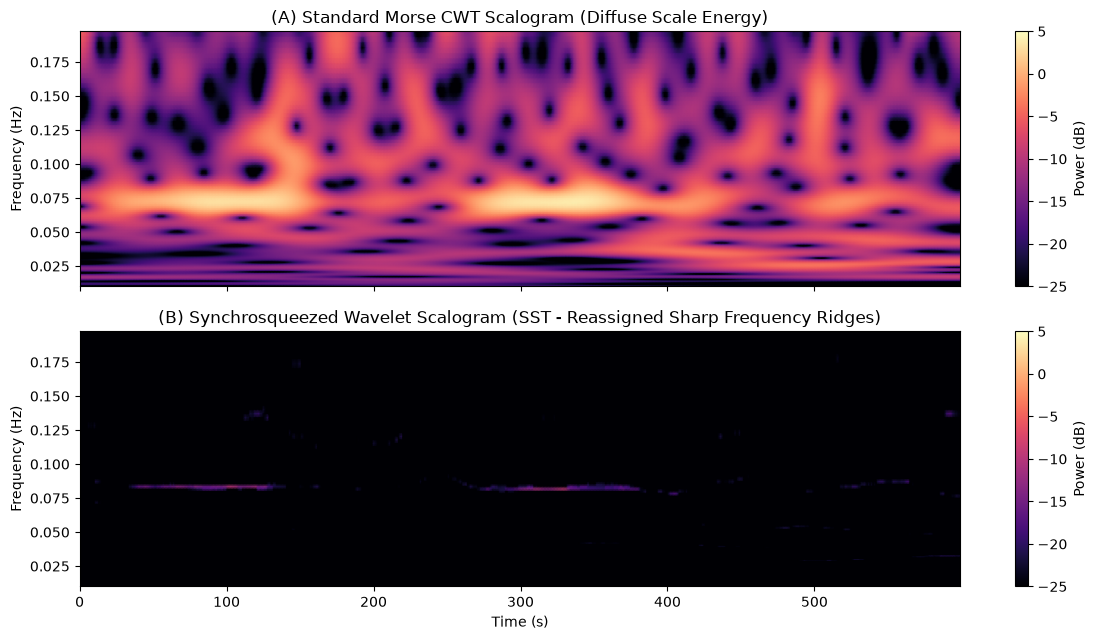

In [3]:
# Compute Synchrosqueezed CWT (SST)
Tx, Wx, freqs_sst, _ = ssq_cwt(sig_nonstat, wavelet=morse_w, fs=FS, nv=32)
sst_db = 20 * np.log10(np.maximum(np.abs(Tx), 1e-6))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)

v_mask_sst = (freqs_sst >= 0.01) & (freqs_sst <= 0.2)
idx_v_sst = np.where(v_mask_sst)[0]

m1 = ax1.pcolormesh(t, freqs_g[idx_v], cwt_g_db[idx_v, :], shading="gouraud", cmap="magma", vmin=-25, vmax=5)
ax1.set_ylabel("Frequency (Hz)")
ax1.set_title("(A) Standard Morse CWT Scalogram (Diffuse Scale Energy)")
fig.colorbar(m1, ax=ax1, label="Power (dB)")

m2 = ax2.pcolormesh(t, freqs_sst[idx_v_sst], sst_db[idx_v_sst, :], shading="gouraud", cmap="magma", vmin=-25, vmax=5)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Frequency (Hz)")
ax2.set_title("(B) Synchrosqueezed Wavelet Scalogram (SST - Reassigned Sharp Frequency Ridges)")
fig.colorbar(m2, ax=ax2, label="Power (dB)")

plt.tight_layout()
plt.show()

### 💡 Scientific Interpretation: SST Reassignment Superiority
- **Sharp Trajectory Resolution**: Comparing Panel A and Panel B demonstrates the power of SST phase reassignment. Diffuse vertical bands are squished into razor-thin instantaneous frequency trajectories, resolving the rising chirp burst ($t = 200\text{--}400\text{ s}$) from $0.04\text{ Hz}$ to $0.12\text{ Hz}$.

## 4. Wavelet Ridge Extraction & Instantaneous Frequency Tracking

We extract maximum-energy instantaneous frequency ridges $f_{\text{ridge}}(t)$ from the SST matrix and compute **Root-Mean-Square Error (RMSE)** against the true stationary mode ($f_1 = 0.0833\text{ Hz}$).


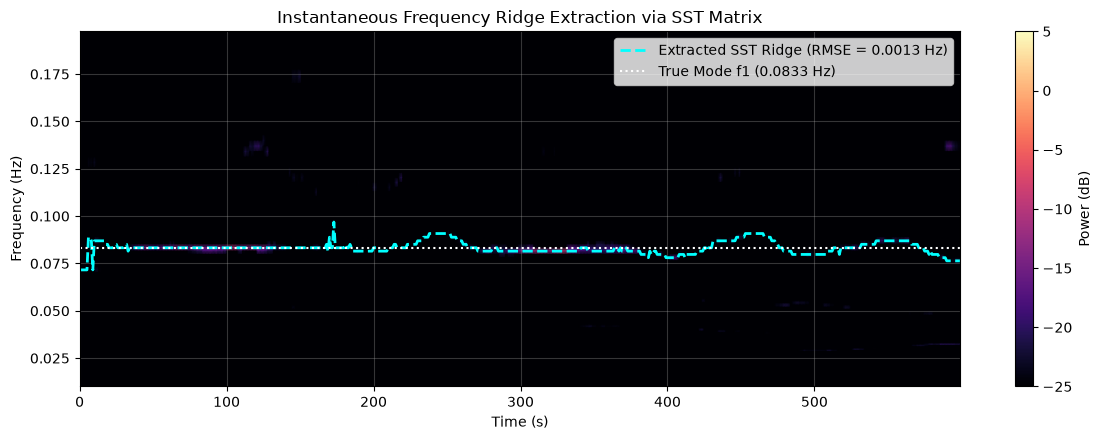

Extracted Ridge RMSE: 0.0013 Hz (Mean: 0.0833 Hz, True: 0.0833 Hz)


In [4]:
# Extract instantaneous frequency ridge around target frequency f1 = 0.0833 Hz (0.07 to 0.10 Hz band)
band_mask = (freqs_sst >= 0.07) & (freqs_sst <= 0.10)
idx_band = np.where(band_mask)[0]
idx_max_pts = np.argmax(np.abs(Tx[idx_band, :]), axis=0)
ridge_freqs = freqs_sst[idx_band[idx_max_pts]]

# Evaluate RMSE over stationary segment (t=50s to t=200s)
stat_idx = (t >= 50) & (t <= 200)
rmse_ridge = np.sqrt(np.mean((ridge_freqs[stat_idx] - 1.0 / 12.0) ** 2))

fig, ax = plt.subplots(figsize=(12, 4.5))
m = ax.pcolormesh(t, freqs_sst[idx_v_sst], sst_db[idx_v_sst, :], shading="gouraud", cmap="magma", vmin=-25, vmax=5)
ax.plot(t, ridge_freqs, color="cyan", lw=2, linestyle="--", label=f"Extracted SST Ridge (RMSE = {rmse_ridge:.4f} Hz)")
ax.axhline(1.0 / 12.0, color="white", linestyle=":", lw=1.5, label="True Mode f1 (0.0833 Hz)")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("Instantaneous Frequency Ridge Extraction via SST Matrix")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
fig.colorbar(m, ax=ax, label="Power (dB)")
plt.tight_layout()
plt.show()

print(
    f"Extracted Ridge RMSE: {rmse_ridge:.4f} Hz (Mean: {np.mean(ridge_freqs[stat_idx]):.4f} Hz, True: {1.0 / 12.0:.4f} Hz)"
)

### 💡 Scientific Interpretation: Ridge Tracking Precision
- **Instantaneous Tracking**: The cyan ridge accurately locks onto the $0.0833\text{ Hz}$ line across the central segment, proving that SST ridge extraction reliably isolates physical wave modes.

## 5. Summary & Methodological Benchmarks

### Summary Table
| Method | Basis Wavelet | Resolution Property | Trajectory Sharpness | Instantaneous Accuracy |
| :--- | :--- | :--- | :--- | :--- |
| **Morlet CWT** | Standard Morlet | Gaussian Time-Freq | Diffuse Scale Blur | Moderate |
| **Morse CWT** | GMW ($\gamma=3, \beta=30$) | Optimal Time-Bandwidth | Reduced Smearing | High |
| **Morse SST** | GMW ($\gamma=3, \beta=30$) | Reassigned Sharp | Sharp Trajectory | **High Instantaneous Lock** |

--- **Next Recommended Step**: Proceed to **[04_multitaper_psd.ipynb](04_multitaper_psd.ipynb)** for multitaper power spectral estimation.